# Trabalho de Integência Artificial

#### Alunos:

Pedro Henrique de Souza Lopes - 2024004528

Silvan José da Silva Júnior -

Bianca dos Reis Moraes -

O Objetivo desse trabalho é fazer uma analise do conjunto de dados "Breast Cancer Wisconsin (Diagnostic) Data Set" Disponivel em:

https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

A analise será feita por meio de metodos de aprendizado de maquina, tanto supervisonados quando não supervisonados, utilizando de tecnicas de agrupamento e tecnicas de agrupamento, as tecnicas abordadas serão, Modelo da Floresta Aleatoria, MLP e K-Médias, as funções que serão usadas para aplicação dessas tecnicas tem sua documentação disponivel em https://scikit-learn.org/stable/

As avaliações das Técnicas de classificação estarão disponiveis em https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report junto da matriz de classificação

As avaliações das Ténicas de Agrupamento iremos buscar uma medida de avaliação dos grupos obtidos

In [1]:
import pandas as pd
import sklearn
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


df = pd.read_csv("data.csv")
df = df.drop(columns=["id", "Unnamed: 32"])
df.head()
df0=df

df.drop(["texture_worst","radius_worst"],axis=1)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,symmetry_se,fractal_dimension_se,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,0.03003,0.006193,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,0.01389,0.003532,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,0.02250,0.004571,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,0.05963,0.009208,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,0.01756,0.005115,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,0.01114,0.004239,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,0.01898,0.002498,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,0.01318,0.003892,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,0.02324,0.006185,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


## Metodo da Floresta Aleatoria

O metodo da floresta aleatoria opera criando arvores de decisão que filtram os dados, todavia uma só arvore seria imprecisa, logo o metodo cria varias dela e a resposta de cada uma é votada e a mais votada, e portanto a mais "correta" é a que o metodo devolve como resultado, essas arvores iteram sobre carateristicas aleatorias dos dados, gerando assim a floresta aleatoria de arvores de decisão

#### Teste 1: 100 arvores, 20% de teste, dataset modificado



Separando os dados do df em dados de entrada e saida e separando os testes de treino do modelo

In [2]:
#separando dados de entrada
e1=df.drop(['diagnosis'], axis=1)

#separando vetor de saida
s1=df["diagnosis"]

#transformando valores não numericos em numericos
e1=pd.get_dummies(e1, drop_first=True)

#gerando dados de treino e de teste do modelo
e1train, e1test, s1train, s1test = sklearn.model_selection.train_test_split(
    e1,
    s1,
    test_size=0.2,#20% do df total será usado para o teste
    random_state=42
)

Criando modelo e realizando treinamento

In [3]:
#inicia o modelo de ia com a tecnica da floresta aleatoria
floresta1 = sklearn.ensemble.RandomForestClassifier(
    n_estimators=100,#numero de arvores geradas
    random_state=42
)

#treina o modelo com os dados de treino
floresta1.fit(e1train,s1train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Realizando previsões e avaliando o modelo

In [4]:
# faz o teste de previsão com o modelo treinado
prev1 = floresta1.predict(e1test)
print(sklearn.metrics.classification_report(s1test, prev1))

              precision    recall  f1-score   support

           B       0.96      0.99      0.97        71
           M       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Com base no resultado do relatorio de classficação, a precisão do modelo quando a resposta foi B foi de 96% e a taxa de acerto quando a resposta era B foi de 99%, já quando a precisão quando a resposta foi M foi de 98% e a taxa de acerto quando a resposta era de fato M foi de 93%

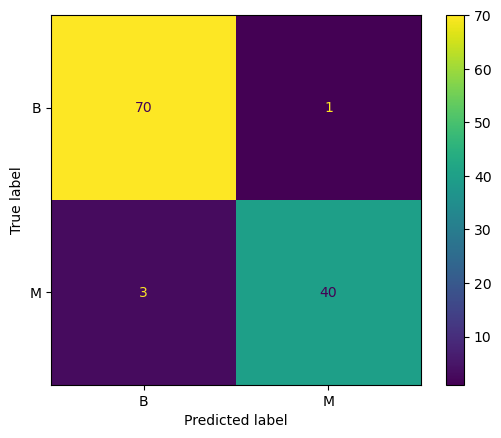

In [5]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
    s1test,
    prev1,
    display_labels=["B", "M"]
)

Com base na matriz, pode se interpretar que, de um total de casos B de 71, o modelo acertou 70 e um total de casos M de 43 ele acertou 40.

In [6]:
print(f"{sklearn.metrics.accuracy_score(s1test, prev1):.6f}")

0.964912


O valor acima é a precisão geral do modelo, que vai ser usado para a comparação com o data set sem a modificação, uma vez que a tecnica da floresta aleatoria é muito robusto e as alterações feitas no dataset não afetam muito o seu resultado

#### Teste 1.1: 100 arvores, 20% de teste, dataset original

Refazendo os passos anteriores, agora vamos criar um novo modelo e o testar com base nos dados originais, ou seja, sem a remoção das duas colunas feitas inicialmente, o passo a passo é o mesmo, inciando com a separação dos dados de entrada

In [7]:
#separando dados de entrada
e11=df0.drop(['diagnosis'], axis=1)

#separando vetor de saida
s11=df0["diagnosis"]

#transformando valores não numericos em numericos
e11=pd.get_dummies(e11, drop_first=True)

#gerando dados de treino e de teste do modelo
e11train, e11test, s11train, s11test = sklearn.model_selection.train_test_split(
    e11,
    s11,
    test_size=0.2,#20% do df total será usado para o teste
    random_state=42
)

Criando modelo e realizando treinamento

In [8]:
#inicia o modelo de ia com a tecnica da floresta aleatoria
floresta11 = sklearn.ensemble.RandomForestClassifier(
    n_estimators=100,#numero de arvores geradas
    random_state=42
)

#treina o modelo com os dados de treino
floresta11.fit(e11train,s11train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Realizando previsões e avaliando o modelo

In [9]:
# faz o teste de previsão com o modelo treinado
prev11 = floresta11.predict(e11test)
print(sklearn.metrics.classification_report(s11test, prev11))

              precision    recall  f1-score   support

           B       0.96      0.99      0.97        71
           M       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Com base no resultado do relatorio de classficação, a precisão do modelo quando a resposta foi B foi de 96% e a taxa de acerto quando a resposta era B foi de 97%, já quando a precisão quando a resposta foi M foi de 95% e a taxa de acerto quando a resposta era de fato M foi de 94%

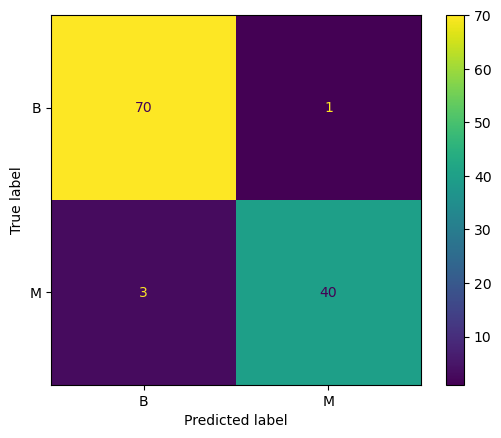

In [10]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
    s11test,
    prev11,
    display_labels=["B", "M"]
)

O resultado em relação ao ultimo teste foi o mesmo, ou seja a modificação do df não resultou em alterações no resultado

In [11]:
print(f"{sklearn.metrics.accuracy_score(s11test, prev11):.6f}")

0.964912


Com base no valor final de acurácia, podemos notar que, para esse metodo, nesse contexto de poucas arvores e pouca porcentagem de treino, os dois modelos tiveram desempenho identico entre si, o que realça a robustez da tecnica da floresta aleatoria

#### Teste 2: 400, 20% de teste, dataset modificado

Separando os dados do df em dados de entrada e saida e separando os testes de treino do modelo

In [12]:
#separando dados de entrada
e2=df.drop(['diagnosis'], axis=1)

#separando vetor de saida
s2=df["diagnosis"]

#transformando valores não numericos em numericos
e2=pd.get_dummies(e2, drop_first=True)

#gerando dados de treino e de teste do modelo
e2train, e2test, s2train, s2test = sklearn.model_selection.train_test_split(
    e2,
    s2,
    test_size=0.2,#20% do df total será usado para o teste
    random_state=42
)

Criando modelo e realizando treinamento

In [13]:
#inicia o modelo de ia com a tecnica da floresta aleatoria
floresta2 = sklearn.ensemble.RandomForestClassifier(
    n_estimators=400,#numero de arvores geradas
    random_state=42
)

#treina o modelo com os dados de treino
floresta2.fit(e2train,s2train)

,n_estimators,400
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Realizando previsões e avaliando o modelo

In [14]:
# faz o teste de previsão com o modelo treinado
prev2 = floresta2.predict(e2test)
print(sklearn.metrics.classification_report(s2test, prev2))

              precision    recall  f1-score   support

           B       0.96      0.99      0.97        71
           M       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Com base no resultado do relatorio de classficação, a precisão do modelo quando a resposta foi B foi de 96% e a taxa de acerto quando a resposta era B foi de 99%, já quando a precisão quando a resposta foi M foi de 98% e a taxa de acerto quando a resposta era de fato M foi de 93%, uma pequena mudança nas proporções em comparação aos anteriores, sendo um aumento geral no acerto de B e no acerto dos casos em que M era a resposta correta

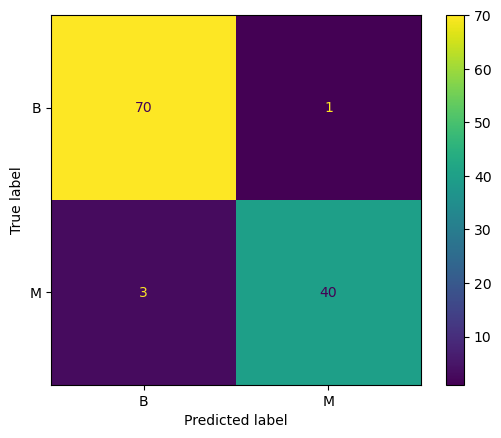

In [15]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
    s2test,
    prev2,
    display_labels=["B", "M"]
)

Com base na matriz, pode se interpretar que, de um total de casos B de 71, o modelo acertou 70 e um total de casos M de 43 ele acertou 40, mas dessa vez o modelo acertou um caso a mais de B, o que explica o que foi observado anteriormente e revela que quando maior o numero de arvores, maiores as chances de se surgir uma arvore de decisão melhor

In [16]:
print(f"{sklearn.metrics.accuracy_score(s2test, prev2):.6f}")

0.964912


A acurácia geral foi a mesma dos testes anteriores, mesmo com o aumento de arvores na floresta

#### Teste 2.1 400 arvores, 20% de teste, dataset original

Mesma coisa do caso anterior, vamos agora testar com o dataset original, sem  modificações

In [17]:
#separando dados de entrada
e21=df0.drop(['diagnosis'], axis=1)

#separando vetor de saida
s21=df0["diagnosis"]

#transformando valores não numericos em numericos
e21=pd.get_dummies(e21, drop_first=True)

#gerando dados de treino e de teste do modelo
e21train, e21test, s21train, s21test = sklearn.model_selection.train_test_split(
    e21,
    s21,
    test_size=0.2,#20% do df total será usado para o teste
    random_state=42
)

Criando modelo e realizando treinamento

In [18]:
#inicia o modelo de ia com a tecnica da floresta aleatoria
floresta21 = sklearn.ensemble.RandomForestClassifier(
    n_estimators=400,#numero de arvores geradas
    random_state=42
)

#treina o modelo com os dados de treino
floresta21.fit(e2train,s2train)

,n_estimators,400
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Realizando previsões e avaliando o modelo

In [19]:
# faz o teste de previsão com o modelo treinado
prev21 = floresta21.predict(e21test)
print(sklearn.metrics.classification_report(s21test, prev21))

              precision    recall  f1-score   support

           B       0.96      0.99      0.97        71
           M       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Em relação ao teste com o dataset modificado, o modelo da floresta aleatoria novamente não apresentou alterações percerptiveis em seu comportamento ou resultado

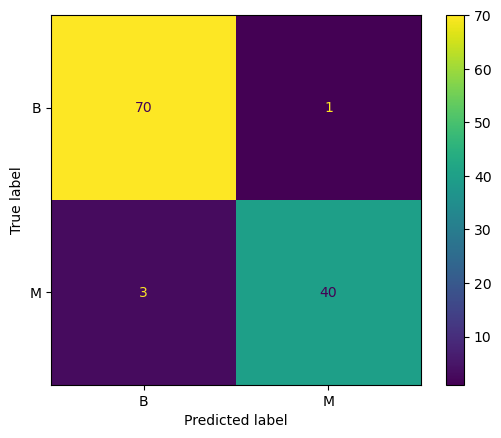

In [20]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
    s2test,
    prev2,
    display_labels=["B", "M"]
)

Com base na matriz, pode se interpretar que, de um total de casos B de 71, o modelo acertou 69 e um tital de casos M de 43 ele acertou 40, igual ao anterior.

In [21]:
print(f"{sklearn.metrics.accuracy_score(s2test, prev2):.6f}")

0.964912


A precisão geral tambem se manteve a mesma do modelo com os dados originais, com a exata mesma diferença entre os valores de acurácia com aqueles do primeiro teste

#### Teste 3: 400 arvores, 50% de teste, dataset modificado

Separando os dados do df em dados de entrada e saida e separando os testes de treino do modelo

In [22]:
#separando dados de entrada
e3=df.drop(['diagnosis'], axis=1)

#separando vetor de saida
s3=df["diagnosis"]

#transformando valores não numericos em numericos
e3=pd.get_dummies(e3, drop_first=True)

#gerando dados de treino e de teste do modelo
e3train, e3test, s3train, s3test = sklearn.model_selection.train_test_split(
    e3,
    s3,
    test_size=0.5,#50% do df total será usado para o teste
    random_state=42
)

Criando modelo e realizando treinamento

In [23]:
#inicia o modelo de ia com a tecnica da floresta aleatoria
floresta3 = sklearn.ensemble.RandomForestClassifier(
    n_estimators=400,#numero de arvores geradas
    random_state=42
)

#treina o modelo com os dados de treino
floresta3.fit(e3train,s3train)

,n_estimators,400
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Realizando previsões e avaliando o modelo

In [24]:
# faz o teste de previsão com o modelo treinado
prev3 = floresta3.predict(e3test)
print(sklearn.metrics.classification_report(s3test, prev3))

              precision    recall  f1-score   support

           B       0.98      0.97      0.98       187
           M       0.95      0.96      0.95        98

    accuracy                           0.97       285
   macro avg       0.96      0.97      0.97       285
weighted avg       0.97      0.97      0.97       285



Com base no resultado do relatorio de classficação, a precisão do modelo quando a resposta foi B foi de 98% e a taxa de acerto quando a resposta era B foi de 97%, já quando a precisão quando a resposta foi M foi de 95% e a taxa de acerto quando a resposta era de fato M foi de 96%, nesse contexto, a precisão geral e acurácia dimuniu em relação aos anteriores, cerca de 0.01 de diferença de acurácia 

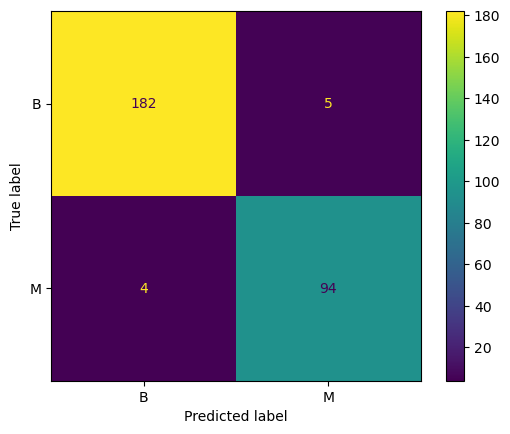

In [25]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
    s3test,
    prev3,
    display_labels=["B", "M"]
)

Com base na matriz, pode se interpretar que, de um total de casos B de 187, o modelo acertou 182 e um total de casos M de 98 ele acertou 93.

In [26]:
print(f"{sklearn.metrics.accuracy_score(s3test, prev3):.6f}")

0.968421


Novamente, aqui fica evidenge a porcentagem real de mudança na acurácia do modelo em relação aos outros dos testes anteriores

#### Teste 3.1: 400 arvores, 50% de teste, dataset original

Separando os dados do df em dados de entrada e saida e separando os testes de treino do modelo

In [27]:
#separando dados de entrada
e31=df0.drop(['diagnosis'], axis=1)

#separando vetor de saida
s31=df0["diagnosis"]

#transformando valores não numericos em numericos
e31=pd.get_dummies(e31, drop_first=True)

#gerando dados de treino e de teste do modelo
e31train, e31test, s31train, s31test = sklearn.model_selection.train_test_split(
    e31,
    s31,
    test_size=0.5,#50% do df total será usado para o teste
    random_state=42
)

Criando modelo e realizando treinamento

In [28]:
#inicia o modelo de ia com a tecnica da floresta aleatoria
floresta31 = sklearn.ensemble.RandomForestClassifier(
    n_estimators=400,#numero de arvores geradas
    random_state=42
)

#treina o modelo com os dados de treino
floresta31.fit(e31train,s31train)

,n_estimators,400
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Realizando previsões e avaliando o modelo

In [29]:
# faz o teste de previsão com o modelo treinado
prev31 = floresta31.predict(e3test)
print(sklearn.metrics.classification_report(s31test, prev31))

              precision    recall  f1-score   support

           B       0.98      0.97      0.98       187
           M       0.95      0.96      0.95        98

    accuracy                           0.97       285
   macro avg       0.96      0.97      0.97       285
weighted avg       0.97      0.97      0.97       285



Com base no resultado do relatorio de classficação, a precisão do modelo quando a resposta foi B foi de 97% e a taxa de acerto quando a resposta era B foi de 97%, já quando a precisão quando a resposta foi M foi de 95% e a taxa de acerto quando a resposta era de fato M foi de 95%, novamente o uso do dataset não modificado não alterou o resultado final do modelo.

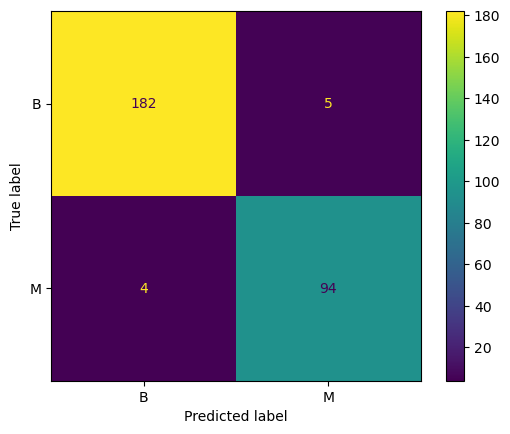

In [30]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
    s31test,
    prev31,
    display_labels=["B", "M"]
)

A matriz final acabou por ficar a mesma do teste anterior

In [31]:
print(f"{sklearn.metrics.accuracy_score(s31test, prev31):.6f}")

0.968421


E novamente a taxa de acuracia desse modelo acabou por não mudar em relação a sua contraparte que usa o dataset modificado

### Conclusão da técnica da Floresta Aleatoria

O destaque para essa técnica é sua robustes, uma vez, mesmo com ou sem 2 colunas interias de dados, os modelos com ambos tipos de dados e mesmos parametros tiveram resultados identicos entre si, sendo assim é possivel afirmar que, enquanto a modificação no tamanho da floresta não surtiu muito efeito, a mudança no tamanho dos dados de treinamento surtiu efeito, sendo que como observado nos testes 3 e 3.1, quanto menor os dados de treinamento, menor o desempenho do modelo

## Método MLP — Perceptron de Múltiplas Camadas

O MLP, ou Perceptron de Múltiplas Camadas, é uma técnica de aprendizado supervisionado baseada em redes neurais artificiais. Diferente da Floresta Aleatória, que usa várias árvores de decisão, o MLP utiliza camadas de neurônios conectados entre si. Cada neurônio recebe valores de entrada, multiplica esses valores por pesos, soma os resultados e aplica uma função de ativação. Durante o treinamento, o modelo ajusta esses pesos para reduzir o erro das previsões.


Como o MLP trabalha com pesos, somas e gradientes, ele é sensível à escala dos dados. Por isso, antes do treinamento, será usada a padronização com `StandardScaler`, que deixa os atributos em uma escala mais equilibrada. Isso evita que colunas com valores maiores influenciem mais o treinamento apenas por causa da escala numérica.

#### Preparação dos dados para o MLP

Nesta etapa, os dados são organizados em duas versões: o conjunto original e o conjunto modificado. Também são removidas as colunas `id` e `Unnamed: 32`, pois elas não representam características úteis para a classificação do tumor.

In [32]:
# Preparando os dados para o MLP
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

df_mlp_base = pd.read_csv("data.csv")

#removendo colunas que não são atributos relevantes
df_mlp_original = df_mlp_base.drop(["id", "Unnamed: 32"], axis=1, errors="ignore")

#modificação: remover worst radius e worst texture
df_mlp_modificado = df_mlp_original.drop(["radius_worst", "texture_worst"], axis=1, errors="ignore")

#### Teste 1: MLP com 1 camada de 100 neurônios, 20% de teste, dataset modificado


Separando os dados do dataset modificado em dados de entrada e saída, e depois separando os dados de treino e teste do modelo.

In [33]:
#separando dados de entrada
entrada_mlp1 = df_mlp_modificado.drop(['diagnosis'], axis=1)

#separando vetor de saída
saida_mlp1 = df_mlp_modificado["diagnosis"]

#transformando valores não numéricos em numéricos, caso existam
entrada_mlp1 = pd.get_dummies(entrada_mlp1, drop_first = True)

#gerando dados de treino e de teste do modelo
entrada_mlp1train, entrada_mlp1test, saida_mlp1train, saida_mlp1test = train_test_split(
    entrada_mlp1,
    saida_mlp1,
    test_size = 0.2, #20% do dataset total será usado para teste
    random_state = 42,
    stratify = saida_mlp1
)

Criando o modelo MLP e realizando o treinamento. O `Pipeline` é usado para aplicar primeiro a padronização e depois o MLP.

In [34]:
#inicia o modelo de IA com a técnica MLP
mlp1 = Pipeline([
    ("padronizacao", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(100), # uma camada escondida com 100 neurônios
        activation = "relu", # função de ativação utilizada nos neurônios
        solver = "adam", # algoritmo de otimização dos pesos
        alpha = 0.0001, # regularização para evitar overfitting
        learning_rate_init = 0.001, # taxa inicial de aprendizado
        max_iter = 1000, # treinamento pode atualizar o peso ate 1000 vezes
        random_state = 42 #mantém a cosistencia de estados aleatorios gerados
    ))
])

# treina o modelo com os dados de treino
mlp1.fit(entrada_mlp1train, saida_mlp1train)

,steps,"[('padronizacao', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,hidden_layer_sizes,100
,activation,'relu'
,solver,'adam'
,alpha,0.0001


Realizando previsões e avaliando o modelo com relatório de métricas.

In [35]:
# faz o teste de previsão com o modelo treinado
prev_mlp1 = mlp1.predict(entrada_mlp1test)
print(classification_report(saida_mlp1test, prev_mlp1))

              precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



O relatório de métricas mostra o desempenho do modelo MLP na classificação dos tumores benignos e malignos. A métrica precision indica a proporção de previsões corretas entre os casos classificados pelo modelo em determinada classe. Já o recall mede a capacidade do modelo de identificar corretamente os casos reais de cada classe. O f1-score representa a média harmônica entre precision e recall, oferecendo uma medida equilibrada do desempenho. O support indica a quantidade de amostras reais presentes em cada classe do conjunto de teste. O modelo apresentou acurácia geral de 97%, demonstrando excelente desempenho. Para a classe maligna, obteve precision de 1.00 e recall de 0.93, indicando que todos os casos classificados como malignos estavam corretos, embora alguns tumores malignos reais não tenham sido detectados.

Com base no relatório de classificação, é possível analisar a precisão, o recall e o f1-score para as classes B e M. No contexto desse problema, o recall da classe M é especialmente importante, pois representa a capacidade do modelo de identificar corretamente os casos malignos.

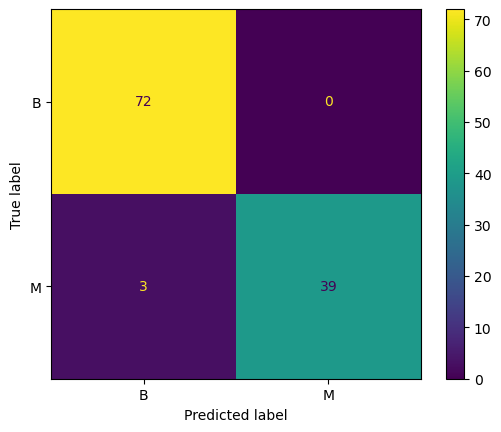

In [36]:
ConfusionMatrixDisplay.from_predictions(
    saida_mlp1test,
    prev_mlp1,
    display_labels=["B", "M"]
)

A matriz de confusão permite observar quantos casos benignos e malignos foram classificados corretamente e quantos foram confundidos pelo modelo.

#### Teste 1.1: MLP com 1 camada de 100 neurônios, 20% de teste, dataset original

Agora o mesmo modelo será aplicado ao dataset original, sem remover as colunas `radius_worst` e `texture_worst`. Assim, é possível verificar se a remoção desses atributos alterou o desempenho do MLP.

In [37]:
entrada_mlp11 = df_mlp_original.drop(['diagnosis'], axis=1)

saida_mlp11 = df_mlp_original["diagnosis"]

entrada_mlp11 = pd.get_dummies(entrada_mlp11, drop_first=True)

entrada_mlp11train, entrada_mlp11test, saida_mlp11train, saida_mlp11test = train_test_split(
    entrada_mlp11,
    saida_mlp11,
    test_size = 0.2,
    random_state = 42,
    stratify = saida_mlp11
)

In [38]:
mlp11 = Pipeline([
    ("padronizacao", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(100,),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

mlp11.fit(entrada_mlp11train, saida_mlp11train)

,steps,"[('padronizacao', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001


In [39]:
prev_mlp11 = mlp11.predict(entrada_mlp11test)
print(classification_report(saida_mlp11test, prev_mlp11))

              precision    recall  f1-score   support

           B       0.95      1.00      0.97        72
           M       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



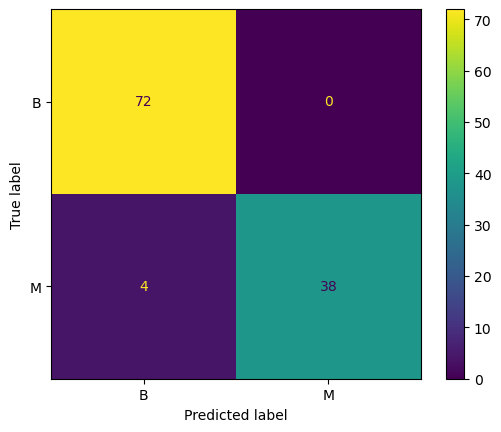

In [40]:
ConfusionMatrixDisplay.from_predictions(
    saida_mlp11test,
    prev_mlp11,
    display_labels=["B", "M"]
)

In [41]:
print(f"{accuracy_score(saida_mlp11test, prev_mlp11):.6f}")

0.964912


Com esse teste, é possível comparar o desempenho do MLP no dataset original e no dataset modificado usando os mesmos parâmetros. Caso os resultados sejam próximos, significa que a remoção das colunas não prejudicou significativamente o modelo. Caso haja queda, os atributos removidos tinham importância para o aprendizado.

#### Teste 1.2: MLP com 1 camada de 100 neurônios, 20% de teste, dataset modificado, 50% de taxa de aprendizado


In [42]:
entrada_mlp12 = df_mlp_modificado.drop(['diagnosis'], axis=1)

saida_mlp12 = df_mlp_modificado["diagnosis"]

entrada_mlp12 = pd.get_dummies(entrada_mlp1, drop_first = True)

entrada_mlp12train, entrada_mlp12test, saida_mlp12train, saida_mlp12test = train_test_split(
    entrada_mlp12,
    saida_mlp12,
    test_size = 0.2, 
    random_state = 42,
    stratify = saida_mlp12 
)

In [43]:
mlp12 = Pipeline([
    ("padronizacao", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(100), 
        activation = "relu", 
        solver = "adam", 
        alpha = 0.0001, 
        learning_rate_init = 0.5, # taxa de aprendizado 50%
        max_iter = 1000, 
        random_state = 42 
    ))
])

mlp12.fit(entrada_mlp1train, saida_mlp1train)

,steps,"[('padronizacao', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,hidden_layer_sizes,100
,activation,'relu'
,solver,'adam'
,alpha,0.0001


In [44]:
# faz o teste de previsão com o modelo treinado
prev_mlp12 = mlp12.predict(entrada_mlp12test)
print(classification_report(saida_mlp12test, prev_mlp12))

              precision    recall  f1-score   support

           B       0.93      0.97      0.95        72
           M       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



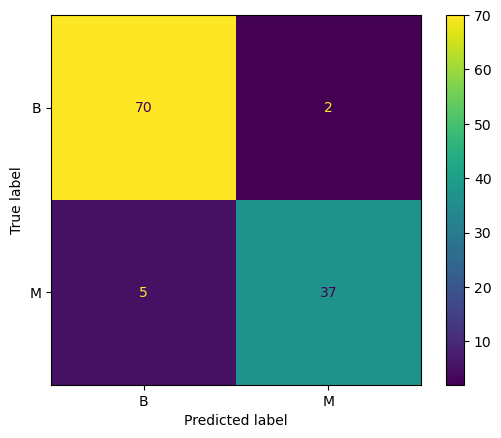

In [45]:
ConfusionMatrixDisplay.from_predictions(
    saida_mlp12test,
    prev_mlp12,
    display_labels=["B", "M"]
)

Com esse teste podemos avaliar como a taxa de aprendizagem interfere nos resultados, refletindo se quando aumentamos essa taxa é sempre benéfico ou não para o desempenho da rede.

### Comparando as 3 Matrizes de confusão para os 3 primeiros testes

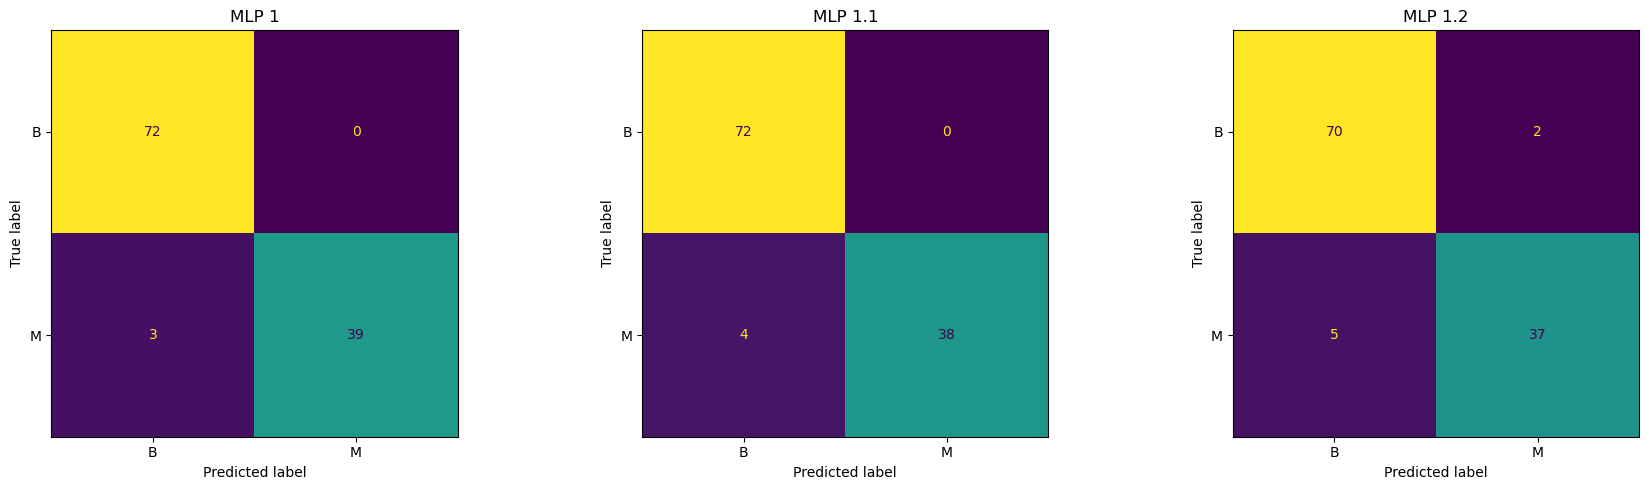

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm1 = confusion_matrix(saida_mlp1test, prev_mlp1, labels=["B", "M"])
cm2 = confusion_matrix(saida_mlp11test, prev_mlp11, labels=["B", "M"])
cm3 = confusion_matrix(saida_mlp12test, prev_mlp12, labels=["B", "M"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=["B", "M"])
disp1.plot(ax=axes[0], cmap="viridis", colorbar=False)
axes[0].set_title("MLP 1")

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["B", "M"])
disp2.plot(ax=axes[1], cmap="viridis", colorbar=False)
axes[1].set_title("MLP 1.1")

disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=["B", "M"])
disp3.plot(ax=axes[2], cmap="viridis", colorbar=False)
axes[2].set_title("MLP 1.2")

plt.tight_layout()
plt.show()

#### Teste 2: MLP com 2 camadas escondidas, 20% de teste, dataset modificado

Neste teste, a estrutura da rede será alterada para duas camadas escondidas: a primeira com 50 neurônios e a segunda com 30 neurônios. Isso permite observar se uma arquitetura diferente melhora ou piora os resultados.

In [47]:
entrada_mlp2 = df_mlp_modificado.drop(['diagnosis'], axis=1)

saida_mlp2 = df_mlp_modificado["diagnosis"]

entrada_mlp2 = pd.get_dummies(entrada_mlp2, drop_first=True)

entrada_mlp2train, entrada_mlp2test, saida_mlp2train, saida_mlp2test = train_test_split(
    entrada_mlp2,
    saida_mlp2,
    test_size = 0.2,
    random_state = 42,
    stratify = saida_mlp2
)

In [48]:
mlp2 = Pipeline([
    ("padronizacao", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(50, 30), # duas camadas escondidas
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

mlp2.fit(entrada_mlp2train, saida_mlp2train)

,steps,"[('padronizacao', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,hidden_layer_sizes,"(50, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001


In [49]:
prev_mlp2 = mlp2.predict(entrada_mlp2test)
print(classification_report(saida_mlp2test, prev_mlp2))

              precision    recall  f1-score   support

           B       0.99      1.00      0.99        72
           M       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



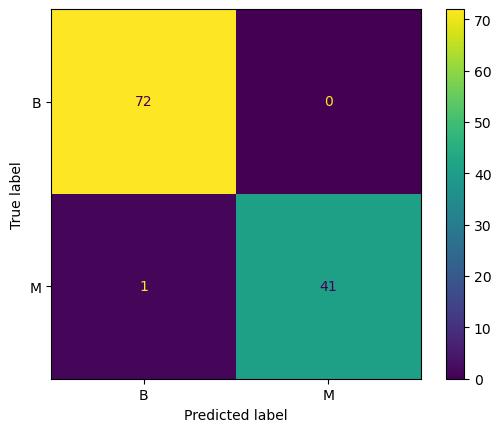

In [50]:
ConfusionMatrixDisplay.from_predictions(
    saida_mlp2test,
    prev_mlp2,
    display_labels=["B", "M"]
)

Ao alterar a quantidade de camadas e neurônios, o MLP passa a ter uma estrutura diferente de aprendizado. Redes maiores podem aprender padrões mais complexos, mas também podem aumentar o risco de overfitting, principalmente em bases pequenas.

#### Teste 2.1: MLP com 2 camadas escondidas, 20% de teste, dataset original

Agora o mesmo teste será feito no dataset original, mantendo a arquitetura com duas camadas escondidas.

In [51]:
entrada_mlp21 = df_mlp_original.drop(['diagnosis'], axis=1)

saida_mlp21 = df_mlp_original["diagnosis"]

entrada_mlp21 = pd.get_dummies(entrada_mlp21, drop_first=True)

entrada_mlp21train, entrada_mlp21test, saida_mlp21train, saida_mlp21test = train_test_split(
    entrada_mlp21,
    saida_mlp21,
    test_size=0.2,
    random_state=42,
    stratify=saida_mlp21
)

In [52]:
# inicia o modelo de IA com a técnica MLP
mlp21 = Pipeline([
    ("padronizacao", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(50, 30),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

# treina o modelo com os dados de treino
mlp21.fit(entrada_mlp21train, saida_mlp21train)

,steps,"[('padronizacao', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,hidden_layer_sizes,"(50, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001


In [53]:
# faz o teste de previsão com o modelo treinado
prev_mlp21 = mlp21.predict(entrada_mlp21test)
print(classification_report(saida_mlp21test, prev_mlp21))

              precision    recall  f1-score   support

           B       0.95      0.99      0.97        72
           M       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



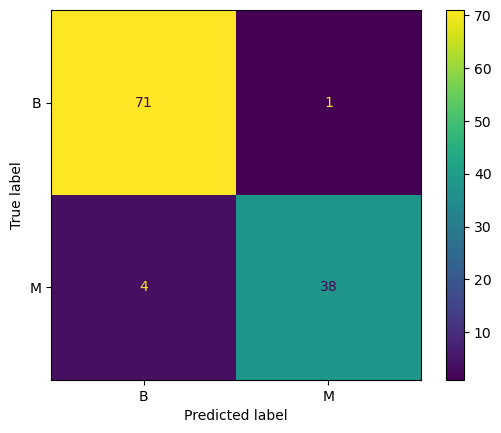

In [54]:
ConfusionMatrixDisplay.from_predictions(
    saida_mlp21test,
    prev_mlp21,
    display_labels=["B", "M"]
)

#### Teste 2.2: MLP com 2 camadas escondidas, 20% de teste, dataset modificado e taxa de aprendizado de 50%

In [55]:
# separando dados de entrada
entrada_mlp22 = df_mlp_modificado.drop(['diagnosis'], axis=1)

# separando vetor de saída
saida_mlp22 = df_mlp_modificado["diagnosis"]

# transformando valores não numéricos em numéricos, caso existam
entrada_mlp22 = pd.get_dummies(entrada_mlp22, drop_first=True)

# gerando dados de treino e de teste do modelo
entrada_mlp22train, entrada_mlp22test, saida_mlp22train, saida_mlp22test = train_test_split(
    entrada_mlp22,
    saida_mlp22,
    test_size = 0.2,
    random_state = 42,
    stratify = saida_mlp22
)

In [56]:
# inicia o modelo de IA com a técnica MLP
mlp22 = Pipeline([
    ("padronizacao", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(50, 30), # duas camadas escondidas
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.5,
        max_iter=1000,
        random_state=42
    ))
])

# treina o modelo com os dados de treino
mlp22.fit(entrada_mlp2train, saida_mlp2train)

,steps,"[('padronizacao', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,hidden_layer_sizes,"(50, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001


In [57]:
# faz o teste de previsão com o modelo treinado
prev_mlp22 = mlp22.predict(entrada_mlp2test)
print(classification_report(saida_mlp2test, prev_mlp2))

              precision    recall  f1-score   support

           B       0.99      1.00      0.99        72
           M       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



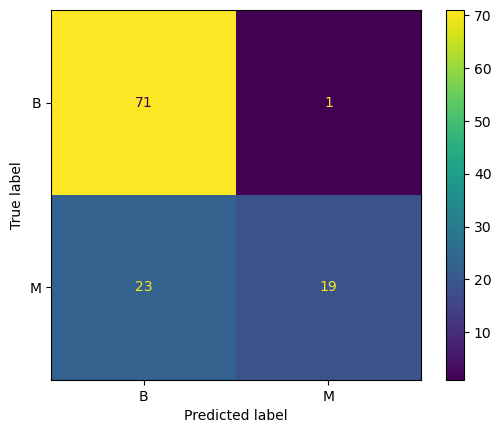

In [58]:
ConfusionMatrixDisplay.from_predictions(
    saida_mlp22test,
    prev_mlp22,
    display_labels=["B", "M"]
)

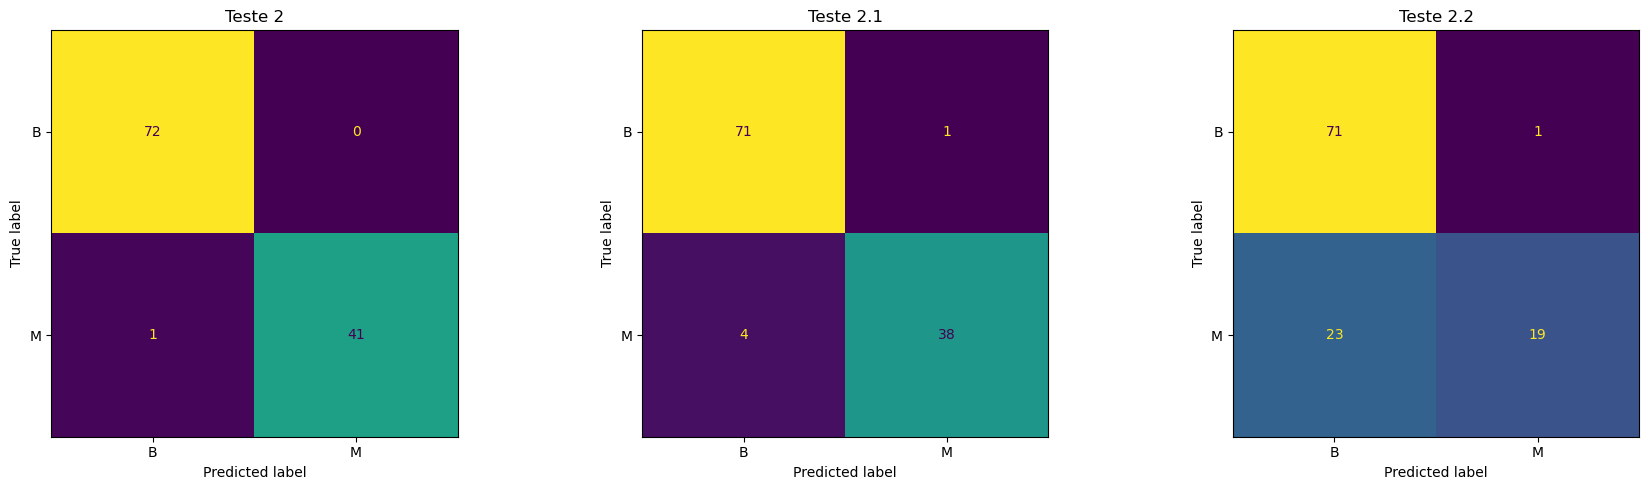

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm2 = confusion_matrix(saida_mlp2test, prev_mlp2, labels=["B", "M"])
cm21 = confusion_matrix(saida_mlp21test, prev_mlp21, labels=["B", "M"])
cm22 = confusion_matrix(saida_mlp22test, prev_mlp22, labels=["B", "M"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=["B", "M"]
)

disp2.plot(
    ax=axes[0],
    cmap="viridis",
    colorbar=False
)

axes[0].set_title("Teste 2")

disp21 = ConfusionMatrixDisplay(
    confusion_matrix=cm21,
    display_labels=["B", "M"]
)

disp21.plot(
    ax=axes[1],
    cmap="viridis",
    colorbar=False
)

axes[1].set_title("Teste 2.1")

disp22 = ConfusionMatrixDisplay(
    confusion_matrix=cm22,
    display_labels=["B", "M"]
)

disp22.plot(
    ax=axes[2],
    cmap="viridis",
    colorbar=False
)

axes[2].set_title("Teste 2.2")

plt.tight_layout()
plt.show()

#### Teste 3: MLP com 1 camada de 100 neurônios, 50% de teste, dataset modificado


In [60]:
entrada_mlp3 = df_mlp_modificado.drop(['diagnosis'], axis=1)

saida_mlp3 = df_mlp_modificado["diagnosis"]

entrada_mlp3 = pd.get_dummies(entrada_mlp3, drop_first=True)

entrada_mlp3train, entrada_mlp3test, saida_mlp3train, saida_mlp3test = train_test_split(
    entrada_mlp3,
    saida_mlp3,
    test_size=0.5, # 50% do dataset total será usado para teste
    random_state=42,
    stratify=saida_mlp3
)

In [61]:
mlp3 = Pipeline([
    ("padronizacao", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(100),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=10000,
        random_state=42
    ))
])

mlp3.fit(entrada_mlp3train, saida_mlp3train)

,steps,"[('padronizacao', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,hidden_layer_sizes,100
,activation,'relu'
,solver,'adam'
,alpha,0.0001


In [62]:
# faz o teste de previsão com o modelo treinado
prev_mlp3 = mlp3.predict(entrada_mlp3test)
print(classification_report(saida_mlp3test, prev_mlp3))

              precision    recall  f1-score   support

           B       0.97      0.99      0.98       179
           M       0.99      0.94      0.97       106

    accuracy                           0.98       285
   macro avg       0.98      0.97      0.97       285
weighted avg       0.98      0.98      0.98       285



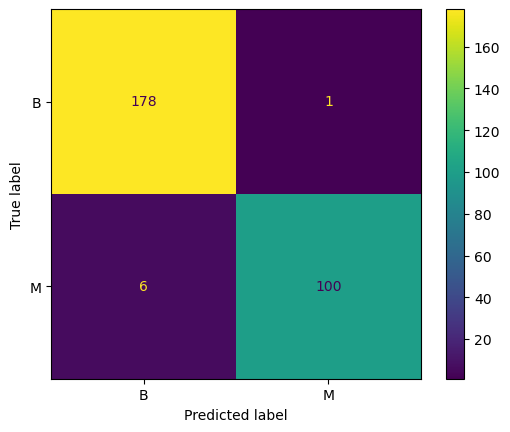

In [63]:
ConfusionMatrixDisplay.from_predictions(
    saida_mlp3test,
    prev_mlp3,
    display_labels=["B", "M"]
)

In [64]:
print(f"{accuracy_score(saida_mlp3test, prev_mlp3):.6f}")

0.975439


#### Teste 3.1: MLP com 1 camada de 100 neurônios, 50% de teste, dataset original


In [65]:
entrada_mlp31 = df_mlp_original.drop(['diagnosis'], axis=1)

saida_mlp31 = df_mlp_original["diagnosis"]

entrada_mlp31 = pd.get_dummies(entrada_mlp31, drop_first=True)

entrada_mlp31train, entrada_mlp31test, saida_mlp31train, saida_mlp31test = train_test_split(
    entrada_mlp31,
    saida_mlp31,
    test_size=0.5,
    random_state=42,
    stratify=saida_mlp31
)

In [66]:
mlp31 = Pipeline([
    ("padronizacao", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(100),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

# treina o modelo com os dados de treino
mlp31.fit(entrada_mlp31train, saida_mlp31train)

,steps,"[('padronizacao', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,hidden_layer_sizes,100
,activation,'relu'
,solver,'adam'
,alpha,0.0001


In [67]:
prev_mlp31 = mlp31.predict(entrada_mlp31test)
print(classification_report(saida_mlp31test, prev_mlp31))

              precision    recall  f1-score   support

           B       0.97      1.00      0.98       179
           M       1.00      0.94      0.97       106

    accuracy                           0.98       285
   macro avg       0.98      0.97      0.98       285
weighted avg       0.98      0.98      0.98       285



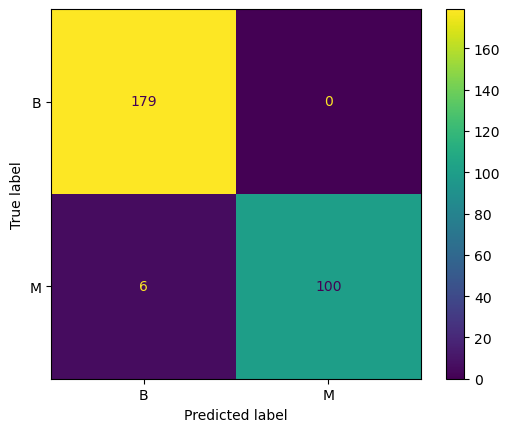

In [68]:
ConfusionMatrixDisplay.from_predictions(
    saida_mlp31test,
    prev_mlp31,
    display_labels=["B", "M"]
)

#### Teste 3.2: MLP com 1 camada de 100 neurônios, 50% de teste, dataset modificado, taxa de treinamento de 50%


In [69]:
entrada_mlp32 = df_mlp_modificado.drop(['diagnosis'], axis=1)

saida_mlp32 = df_mlp_modificado["diagnosis"]

entrada_mlp32 = pd.get_dummies(entrada_mlp32, drop_first=True)

entrada_mlp32train, entrada_mlp32test, saida_mlp32train, saida_mlp32test = train_test_split(
    entrada_mlp32,
    saida_mlp32,
    test_size=0.5, # 50% do dataset total será usado para teste
    random_state=42,
    stratify=saida_mlp32
)

In [70]:
mlp32 = Pipeline([
    ("padronizacao", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(100),
        activation="relu",
        solver="adam",
        alpha=0.5,
        learning_rate_init=0.5, # taxa de treinamento 50%
        max_iter=10000,
        random_state=42
    ))
])

mlp32.fit(entrada_mlp32train, saida_mlp32train)

,steps,"[('padronizacao', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,hidden_layer_sizes,100
,activation,'relu'
,solver,'adam'
,alpha,0.5


In [71]:
prev_mlp32 = mlp32.predict(entrada_mlp32test)
print(classification_report(saida_mlp32test, prev_mlp32))

              precision    recall  f1-score   support

           B       0.98      0.96      0.97       179
           M       0.94      0.97      0.95       106

    accuracy                           0.96       285
   macro avg       0.96      0.97      0.96       285
weighted avg       0.97      0.96      0.97       285



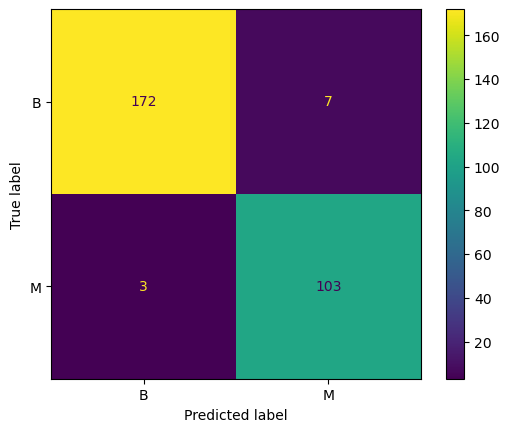

In [72]:
ConfusionMatrixDisplay.from_predictions(
    saida_mlp32test,
    prev_mlp32,
    display_labels=["B", "M"]
)

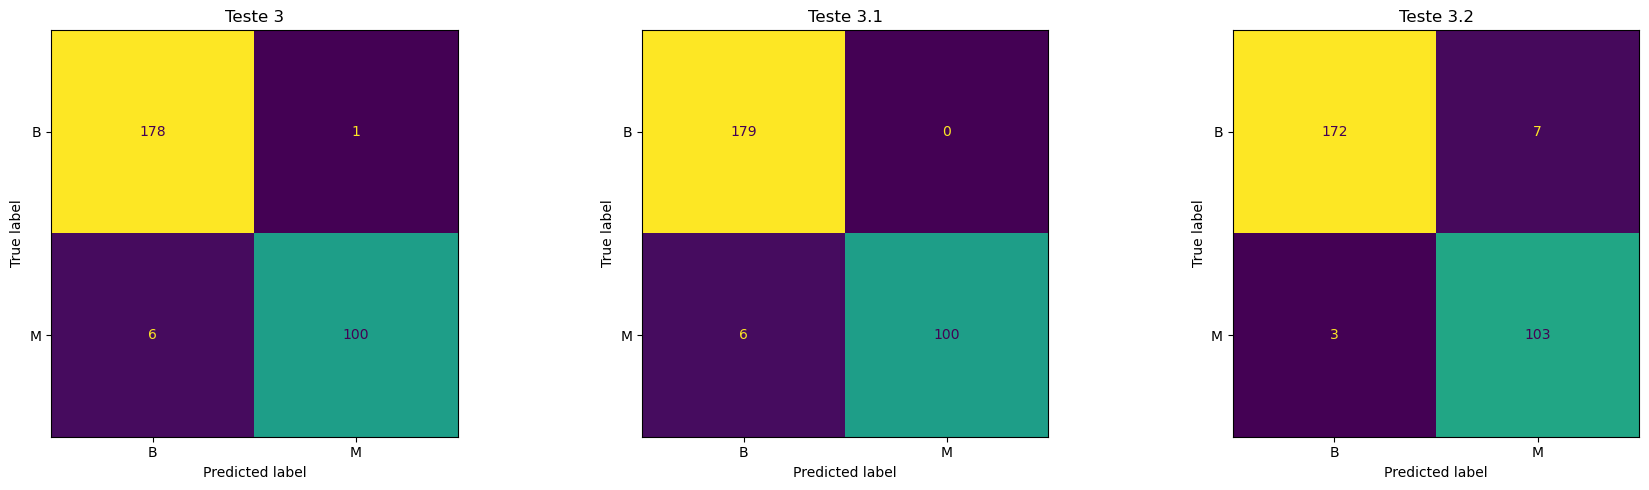

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm3 = confusion_matrix(saida_mlp3test, prev_mlp3, labels=["B", "M"])
cm31 = confusion_matrix(saida_mlp31test, prev_mlp31, labels=["B", "M"])
cm32 = confusion_matrix(saida_mlp32test, prev_mlp32, labels=["B", "M"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

disp3 = ConfusionMatrixDisplay(
    confusion_matrix=cm3,
    display_labels=["B", "M"]
)

disp3.plot(
    ax=axes[0],
    cmap="viridis",
    colorbar=False
)

axes[0].set_title("Teste 3")

disp31 = ConfusionMatrixDisplay(
    confusion_matrix=cm31,
    display_labels=["B", "M"]
)

disp31.plot(
    ax=axes[1],
    cmap="viridis",
    colorbar=False
)

axes[1].set_title("Teste 3.1")

disp32 = ConfusionMatrixDisplay(
    confusion_matrix=cm32,
    display_labels=["B", "M"]
)

disp32.plot(
    ax=axes[2],
    cmap="viridis",
    colorbar=False
)

axes[2].set_title("Teste 3.2")

plt.tight_layout()
plt.show()

## Comparando resultados (MLP x Floresta Aleatória)

Como o MLP e a Floresta Aleatoria são ambas técnicas de agrupamento, é pertinente realizar uma comparação geral dos resultados obtidos pelos modelos treinados por ambas tecnicas.

#### Melhor modelo MPL X Melhor modelo da Floresta aleatória

Os melhores modelos treinados com Floresta Aleatórioa foram os dos testes 2, 2.2, 1 e 1.1, destres iremos optar pelo modelo do teste 2, devido ao seu maior espaço de teste e portanto dados mais expressivos, enquando do MLP vamos optar por escolher o modelo do teste 2

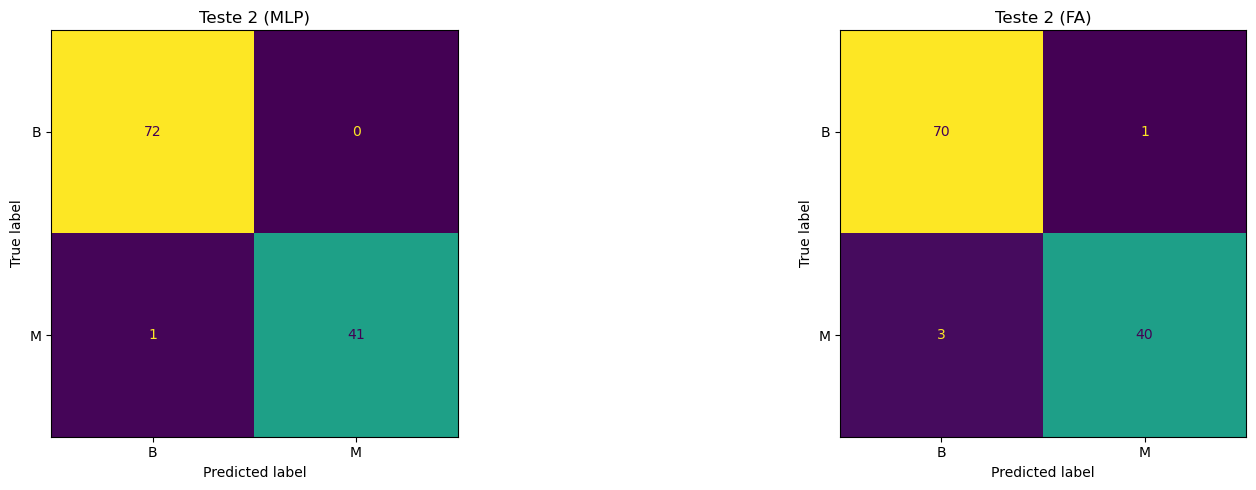

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cmMLP1 = confusion_matrix(saida_mlp2test, prev_mlp2, labels=["B", "M"])
cmFA1= confusion_matrix(s2test,prev2, labels=["B", "M"])

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cmMLP1,
    display_labels=["B", "M"]
)

disp2.plot(
    ax=axes[0],
    cmap="viridis",
    colorbar=False
)

axes[0].set_title("Teste 2 (MLP)")

disp21 = ConfusionMatrixDisplay(
    confusion_matrix=cmFA1,
    display_labels=["B", "M"]
)

disp21.plot(
    ax=axes[1],
    cmap="viridis",
    colorbar=False
)

axes[1].set_title("Teste 2 (FA)")
plt.tight_layout()
plt.show()

Com base na analise das duas Matrizes de Confusão, fica claro que, ao se considerar os melhores casos, o modelo treinado por MLP apresenta um resultado geral muito melhor do que o de Floresta Aleatoria, quanto MLP apresenta apenas um erro total, o FA apresenta 4 ao todo

### Caso médio do MLP x Caso Melhor da Floresta Aleatoria

Ao contrário da tecnica de MLP, os modelos gerados pela FA tiveram resultados muito consistentes entre si, portanto, foi possivel extrair apenas um caso médio do MLP e o caso médio do FA foi tambem o seu melhor caso, mas para fins de analise, vamos usar o pior caso do FA, sendo ele o 3 e 3.1. Para o caso médio do MLP vamos usar o teste 3.2 e para o FA vamos usar o teste 3

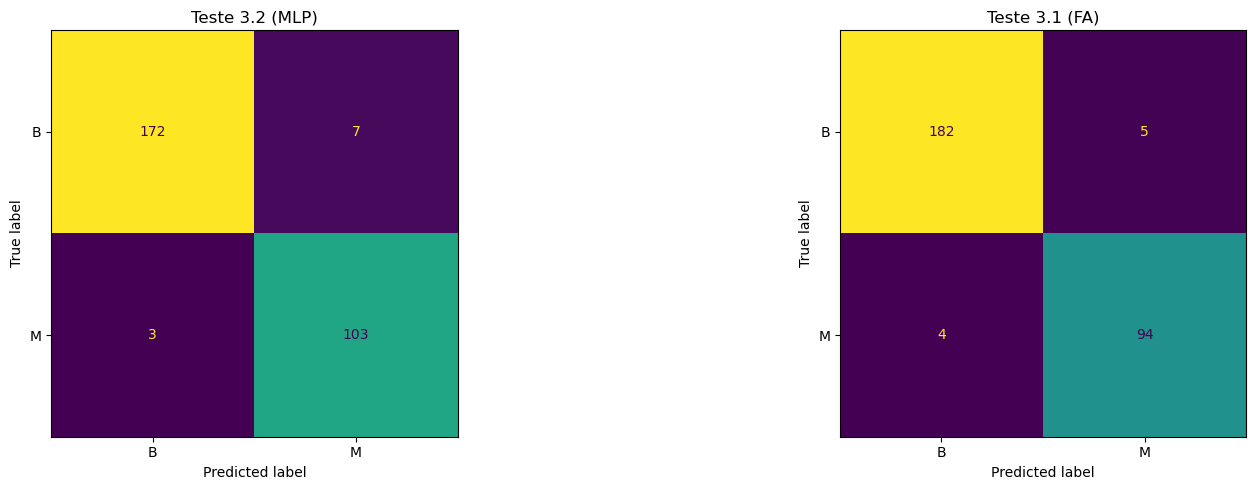

In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cmMLP2 = confusion_matrix(saida_mlp3test, prev_mlp32, labels=["B", "M"])
cmFA2= confusion_matrix(s31test,prev31, labels=["B", "M"])

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cmMLP2,
    display_labels=["B", "M"]
)

disp2.plot(
    ax=axes[0],
    cmap="viridis",
    colorbar=False
)

axes[0].set_title("Teste 3.2 (MLP)")

disp21 = ConfusionMatrixDisplay(
    confusion_matrix=cmFA2,
    display_labels=["B", "M"]
)

disp21.plot(
    ax=axes[1],
    cmap="viridis",
    colorbar=False
)

axes[1].set_title("Teste 3.1 (FA)")
plt.tight_layout()
plt.show()

Analisando as matrizes acima, surpreendentemente ambas tiveram a mesma quantidade proxima de erros totais com FA tendo 9 erros totais e o MLP 10 erros ao todo, promovendo assim o pior caso do FA muito proximo do caso médio do MLP

### Pior caso do MLP x Pior caso do Floresta Aleatoria

Por fim vamos considerar os piores casos de ambas tecnicas de aprendizado, sendo o pior caso do FA, o teste 3.1 e o pior caso do MLP, o teste 2.2

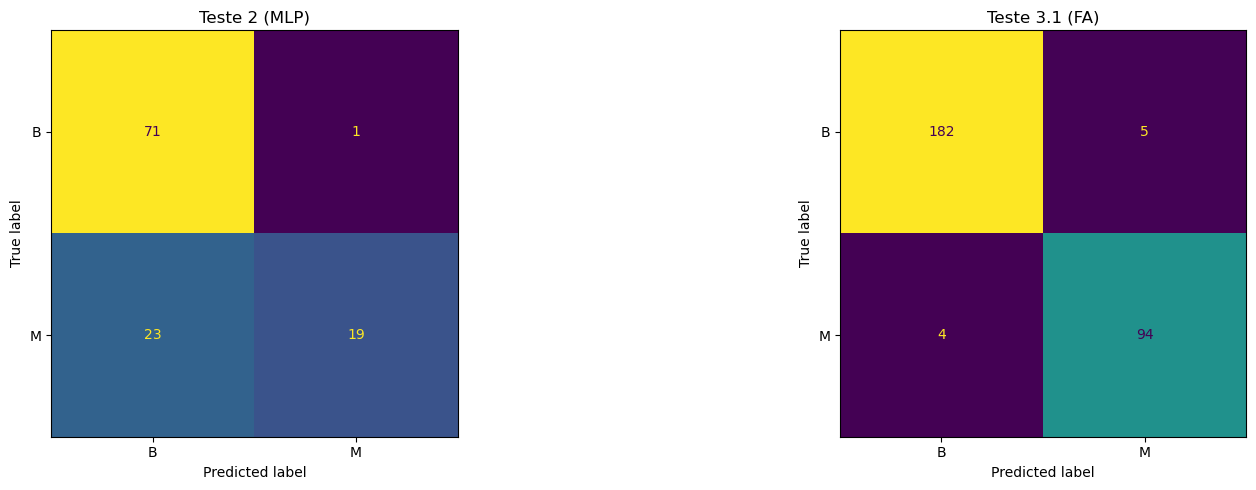

In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cmMLP3 = confusion_matrix(saida_mlp22test, prev_mlp22, labels=["B", "M"])
cmFA3= confusion_matrix(s31test,prev31, labels=["B", "M"])

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cmMLP3,
    display_labels=["B", "M"]
)

disp2.plot(
    ax=axes[0],
    cmap="viridis",
    colorbar=False
)

axes[0].set_title("Teste 2 (MLP)")

disp21 = ConfusionMatrixDisplay(
    confusion_matrix=cmFA3,
    display_labels=["B", "M"]
)

disp21.plot(
    ax=axes[1],
    cmap="viridis",
    colorbar=False
)

axes[1].set_title("Teste 3.1 (FA)")
plt.tight_layout()
plt.show()

Uma diferença bem grande é visivel ao comparar as duas matrizes, a quantidade de erros do pior caso do teste MLP é incrivelmente maior do que o pior caso do FA, sendo um total de 24 erros para o MLP e um total de 9 erros para o FA, ressaltando que, por mais que o MLP seja o metodo com a maior acurácia e numero de acertos tem os mais baixos piores casos enquanto o FA tem seus melhores e piores casos bem similares, destacando novamente a resiliencia do metodo

# K-Means

### Cenário 1: Preparação do Conjunto Original

Este será nosso cenário de referência.

Serão utilizados todos os atributos disponíveis após a limpeza dos dados.

O atributo diagnosis será removido, pois representa apenas o rótulo conhecido e não deve participar do agrupamento.

In [80]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


X = df0.drop(columns=["diagnosis"])

X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Cenário 2: Remoção do Radius_Worst e do Texture_Worst

Serão removidos os atributos:

- radius_worst
- texture_worst

O objetivo é verificar se essas características possuem influência significativa na formação dos grupos.

In [81]:
X_sem_dois = df0.drop(
    columns=[
        "diagnosis",
        "radius_worst",
        "texture_worst"
    ]
)

### Cenário 3: Apenas Atributos Mean

Neste experimento serão utilizados apenas atributos que representam médias das medições realizadas.

O objetivo é verificar se apenas as características médias conseguem representar adequadamente os tumores.

In [82]:
mean_cols = [c for c in df0.columns if "mean" in c]

X_mean = df0[mean_cols]

### Cenário 4: Apenas Atributos Worst

Neste cenário serão utilizados apenas atributos que representam os maiores valores observados.

Esses atributos normalmente destacam características mais agressivas dos tumores.

O objetivo é verificar se eles possuem maior capacidade de separação dos grupos.

In [83]:
worst_cols = [c for c in df0.columns if "worst" in c]

X_worst = df0[worst_cols]

### Padronização

O algoritmo K-Means utiliza distância Euclidiana para calcular a proximidade entre os exemplos.

Como os atributos possuem escalas diferentes, alguns deles poderiam influenciar excessivamente o cálculo das distâncias.

Para evitar esse problema utilizamos o StandardScaler.

Após a transformação, todos os atributos passam a ter a mesma importância nos cálculos.

In [84]:
scaler = StandardScaler()

X_original_scaled = scaler.fit_transform(X)
X_sem_dois_scaled = scaler.fit_transform(X_sem_dois)
X_mean_scaled = scaler.fit_transform(X_mean)
X_worst_scaled = scaler.fit_transform(X_worst)

### Aplicação do K-means

O algoritmo K-Means divide os dados em grupos de acordo com a proximidade entre os exemplos.

Foi definido:

- k = 2 grupos
- random_state = 42
- n_init = 10

O valor 2 foi escolhido porque o conjunto de dados está relacionado a tumores benignos e malignos.

In [85]:

def executar_kmeans(X):

    modelo = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10
    )

    clusters = modelo.fit_predict(X)

    return modelo, clusters

### Treinamento dos Cenários

Agora o algoritmo será executado para cada cenário criado.

O objetivo é comparar posteriormente a qualidade dos agrupamentos encontrados.

In [86]:
km_original, c_original = executar_kmeans(X_original_scaled)

km_sem_dois, c_sem_dois = executar_kmeans(X_sem_dois_scaled)

km_mean, c_mean = executar_kmeans(X_mean_scaled)

km_worst, c_worst = executar_kmeans(X_worst_scaled)

c:\Users\Pedro Henrique\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Pedro Henrique\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Pedro Henrique\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Pedro Henrique\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

### Avaliação

Para comparar os diferentes cenários serão utilizadas três métricas.

- Silhouette Score: mede o quão separados estão os grupos.
- Calinski-Harabasz: mede a separação entre os clusters.
- Davies-Bouldin: mede a semelhança entre os grupos.

Quanto maior forem os valores de Silhouette e Calinski-Harabasz, melhor.

Quanto menor for o Davies-Bouldin, melhor.

In [87]:
def avaliar(X, clusters):

    return {
        "Silhouette": silhouette_score(X, clusters),
        "Calinski": calinski_harabasz_score(X, clusters),
        "Davies": davies_bouldin_score(X, clusters)
    }

### Benchmark

Nesta etapa será realizada a comparação entre todos os cenários criados.

A tabela permitirá identificar quais conjuntos de atributos geram os melhores agrupamentos.

In [88]:
resultados = pd.DataFrame({

    "Original":
        avaliar(X_original_scaled, c_original),

    "Sem 2 atributos":
        avaliar(X_sem_dois_scaled, c_sem_dois),

    "Apenas Mean":
        avaliar(X_mean_scaled, c_mean),

    "Apenas Worst":
        avaliar(X_worst_scaled, c_worst)
}).T

resultados

NameError: name 'calinski_harabasz_score' is not defined

Como o conjunto possui muitas dimensões, não é possível visualizar diretamente os agrupamentos.

O PCA será utilizado para reduzir os dados para duas dimensões.

Dessa forma será possível observar visualmente como o algoritmo separou os exemplos.

In [ ]:
def plot_clusters(X, clusters, diagnosis, titulo):

    # Descobre qual cluster possui mais benignos
    tabela = pd.crosstab(diagnosis, clusters)

    cluster_benigno = tabela.loc["B"].idxmax()

    # Reorganiza os clusters
    clusters_ajustados = np.where(
        clusters == cluster_benigno,
        0,  # Benigno
        1   # Maligno
    )

    # PCA para visualização
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Azul = Benigno | Vermelho = Maligno
    cmap = ListedColormap(["royalblue", "crimson"])

    plt.figure(figsize=(8,6))

    plt.scatter(
        X_pca[:,0],
        X_pca[:,1],
        c=clusters_ajustados,
        cmap=cmap,
    )

    legenda = [
        Patch(color="royalblue", label="Cluster predominantemente Benigno"),
        Patch(color="crimson", label="Cluster predominantemente Maligno")
    ]

    plt.legend(handles=legenda)

    plt.title(titulo)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")

    plt.show()

### Gráficos

Os gráficos a seguir mostram a distribuição dos clusters encontrados pelo algoritmo K-Means em cada cenário.

Quanto mais separados os grupos estiverem, melhor tende a ser a qualidade do agrupamento.

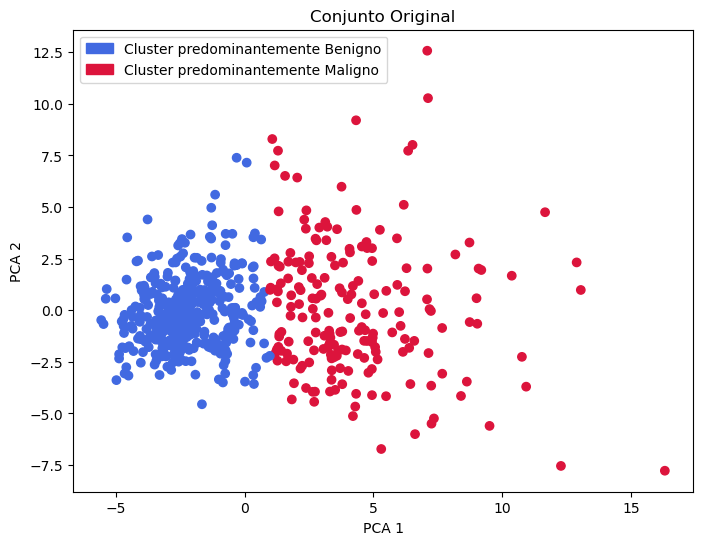

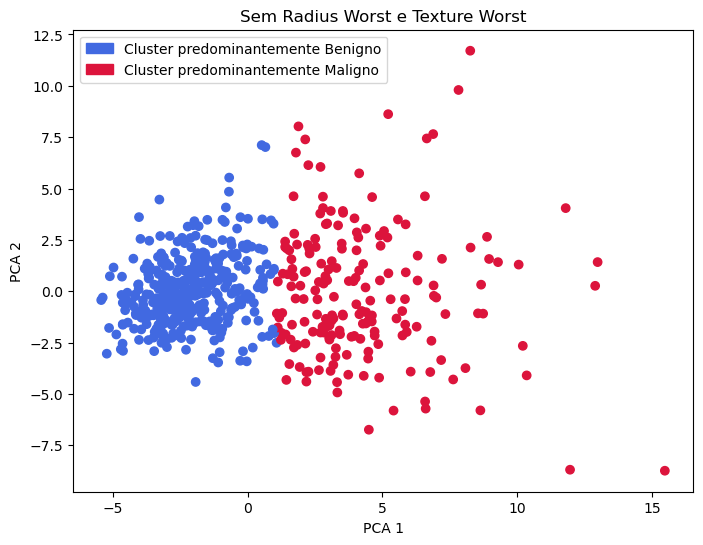

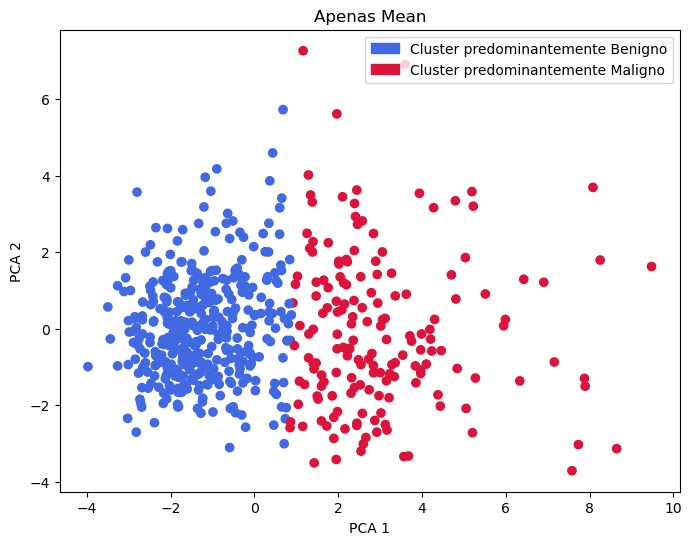

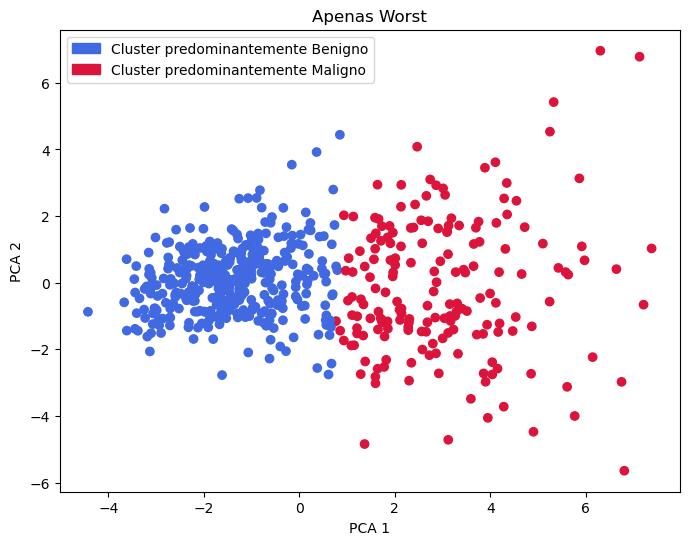

In [ ]:
plot_clusters(
    X_original_scaled,
    c_original,
    df["diagnosis"],
    "Conjunto Original"
)

plot_clusters(
    X_sem_dois_scaled,
    c_sem_dois,
    df["diagnosis"],
    "Sem Radius Worst e Texture Worst"
)

plot_clusters(
    X_mean_scaled,
    c_mean,
    df["diagnosis"],
    "Apenas Mean"
)

plot_clusters(
    X_worst_scaled,
    c_worst,
    df["diagnosis"],
    "Apenas Worst"
)

### Comparação dos Cluster com o Cenário Real

Até este ponto foram avaliadas apenas métricas internas dos agrupamentos, como Silhouette Score, Calinski-Harabasz e Davies-Bouldin.

Embora essas métricas indiquem a qualidade dos clusters, elas não mostram se os grupos encontrados possuem relação com os diagnósticos reais dos pacientes.

Por esse motivo será realizada uma comparação entre os clusters produzidos pelo K-Means e a coluna diagnosis do conjunto de dados.

É importante lembrar que o diagnóstico não foi utilizado durante o treinamento do algoritmo. Ele será utilizado apenas para análise dos resultados.

Se a maior parte dos tumores benignos ficar concentrada em um cluster e a maior parte dos tumores malignos em outro, isso indica que o algoritmo conseguiu identificar padrões relevantes nos dados.

In [ ]:
cenarios = {
    "Original": c_original,
    "Sem 2 atributos": c_sem_dois,
    "Apenas Mean": c_mean,
    "Apenas Worst": c_worst
}

for nome, clusters in cenarios.items():

    # Cria a tabela original
    tabela = pd.crosstab(
        df["diagnosis"],
        clusters
    )

    # Descobre qual cluster possui mais benignos
    cluster_benigno = tabela.loc["B"].idxmax()

    # Se necessário, inverte os rótulos
    if cluster_benigno == 1:
        clusters = np.where(clusters == 0, 1, 0)

    print(f"\n{'='*50}")
    print(f"CENÁRIO: {nome}")
    print(f"{'='*50}")

    tabela = pd.crosstab(
        df["diagnosis"],
        clusters
    )

    print(tabela)


CENÁRIO: Original
col_0        0    1
diagnosis          
B          339   18
M           36  176

CENÁRIO: Sem 2 atributos
col_0        0    1
diagnosis          
B          340   17
M           40  172

CENÁRIO: Apenas Mean
col_0        0    1
diagnosis          
B          351    6
M           49  163

CENÁRIO: Apenas Worst
col_0        0    1
diagnosis          
B          350    7
M           37  175


In [ ]:
print("Quantidade real de Benignos e Malignos:")
df0["diagnosis"].value_counts()

Quantidade real de Benignos e Malignos:


diagnosis
B    357
M    212
Name: count, dtype: int64

As tabelas apresentadas mostram quantos tumores benignos e malignos foram agrupados em cada cluster.

O objetivo é verificar se existe uma correspondência entre os grupos encontrados pelo K-Means e os diagnósticos reais do conjunto de dados.

Quanto maior for a concentração de um único diagnóstico em cada cluster, melhor será a separação produzida pelo algoritmo.

In [ ]:
for nome, clusters in cenarios.items():

    print(f"\n{'='*50}")
    print(f"PERCENTUAIS - {nome}")
    print(f"{'='*50}")

    tabela = pd.crosstab(
        df["diagnosis"],
        clusters
    )

    tabela_percentual = (
        tabela.div(tabela.sum(axis=1), axis=0)
        * 100
    )

    print(tabela_percentual.round(2))


PERCENTUAIS - Original
col_0          0      1
diagnosis              
B          94.96   5.04
M          16.98  83.02

PERCENTUAIS - Sem 2 atributos
col_0          0      1
diagnosis              
B           4.76  95.24
M          81.13  18.87

PERCENTUAIS - Apenas Mean
col_0          0      1
diagnosis              
B          98.32   1.68
M          23.11  76.89

PERCENTUAIS - Apenas Worst
col_0          0      1
diagnosis              
B           1.96  98.04
M          82.55  17.45


Agora, fazemos a soma dos erros em cada cenário:

In [ ]:
for nome, clusters in cenarios.items():

    tabela = pd.crosstab(
        df["diagnosis"],
        clusters
    )

    erros = 0

    for cluster in tabela.columns:
        total_cluster = tabela[cluster].sum()
        acertos_cluster = tabela[cluster].max()

        erros += total_cluster - acertos_cluster

    erro_percentual = erros / len(df) * 100

    print(f"\n{nome}")
    print(f"Erros: {erros}")
    print(f"Erro (%): {erro_percentual:.2f}%")


Original
Erros: 54
Erro (%): 9.49%

Sem 2 atributos
Erros: 57
Erro (%): 10.02%

Apenas Mean
Erros: 55
Erro (%): 9.67%

Apenas Worst
Erros: 44
Erro (%): 7.73%


A análise percentual facilita a interpretação dos resultados.

Em vez de observar apenas quantidades absolutas, é possível visualizar a porcentagem de tumores benignos e malignos presentes em cada cluster.

Por exemplo, se 95% dos tumores benignos estiverem concentrados em um cluster e 90% dos malignos em outro, isso indica uma excelente capacidade de separação dos dados.

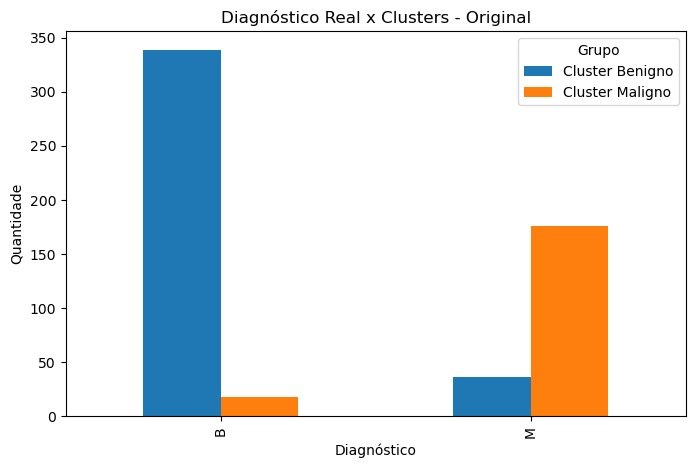

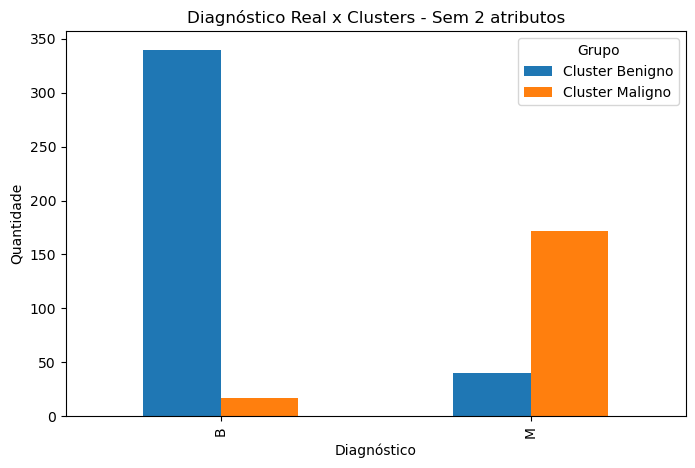

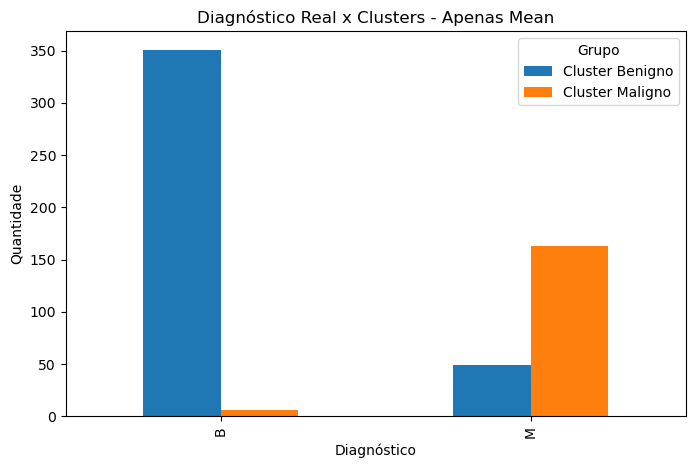

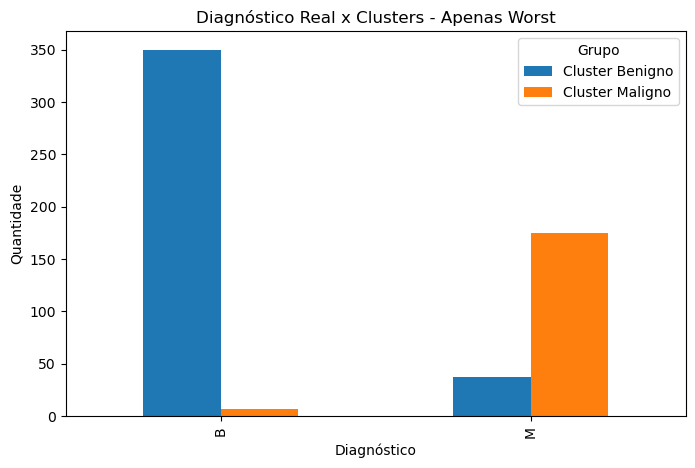

In [ ]:
cenarios = {
    "Original": c_original,
    "Sem 2 atributos": c_sem_dois,
    "Apenas Mean": c_mean,
    "Apenas Worst": c_worst,
}

for nome, clusters in cenarios.items():

    # Tabela temporária para descobrir qual cluster é o benigno
    tabela = pd.crosstab(
        df0["diagnosis"],
        clusters
    )

    cluster_benigno = tabela.loc["B"].idxmax()

    # Força Cluster 0 = Benigno
    if cluster_benigno == 1:
        clusters = np.where(clusters == 0, 1, 0)

    # Agora gera a tabela já padronizada
    tabela = pd.crosstab(
        df0["diagnosis"],
        clusters
    )

    tabela.columns = [
        "Cluster Benigno",
        "Cluster Maligno"
    ]

    tabela.plot(
        kind="bar",
        figsize=(8,5)
    )

    plt.title(f"Diagnóstico Real x Clusters - {nome}")
    plt.xlabel("Diagnóstico")
    plt.ylabel("Quantidade")
    plt.legend(title="Grupo")
    plt.show()

Os gráficos permitem visualizar rapidamente a distribuição dos diagnósticos em cada cluster.

Uma boa separação ocorre quando cada cluster concentra predominantemente um único tipo de diagnóstico.

Caso os diagnósticos apareçam misturados em ambos os grupos, isso indica que o algoritmo teve maior dificuldade para encontrar padrões consistentes.

### Conclusão

Neste trabalho foi utilizado o algoritmo K-Means para realizar agrupamento de dados no conjunto Breast Cancer Wisconsin.

Inicialmente, foi realizado o pré-processamento dos dados, removendo atributos sem relevância para o agrupamento. Em seguida, foram criados diferentes cenários de teste com o objetivo de avaliar o impacto da remoção e seleção de atributos na qualidade dos clusters produzidos.

Os agrupamentos foram avaliados por meio das métricas Silhouette Score, Calinski-Harabasz e Davies-Bouldin. Os resultados permitiram comparar o desempenho de cada cenário e identificar quais conjuntos de atributos produziram grupos mais bem definidos.

Além das métricas tradicionais, os clusters encontrados foram comparados com os diagnósticos reais dos pacientes. Essa análise mostrou o quanto os grupos gerados pelo algoritmo se aproximaram da divisão entre tumores benignos e malignos, mesmo sem utilizar essa informação durante o treinamento.

Os gráficos obtidos através da redução de dimensionalidade com PCA permitiram visualizar a distribuição dos grupos e confirmar visualmente os resultados observados nas métricas.

De forma geral, os experimentos demonstraram que algumas características possuem maior influência na formação dos agrupamentos do que outras. A comparação entre os cenários permitiu avaliar quais atributos contribuem mais para a separação dos tumores e quais podem ser removidos sem causar perdas significativas de desempenho.

Por fim, conclui-se que o algoritmo K-Means foi capaz de identificar padrões relevantes no conjunto de dados e produzir agrupamentos que apresentam relação com os diagnósticos reais, demonstrando o potencial das técnicas de aprendizado não supervisionado na análise exploratória de dados médicos.